# MNIST Digit Classification — Step by Step
### From a Basic Network to a Regularized One

Stages: Baseline → Overfit → Dropout → L2 → L1 → L1+L2 → Compare

---

## Stage 1 — Baseline
### Step 1.1 — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow {tf.__version__} ready ✅")

TensorFlow 2.21.0 ready ✅


### Step 1.2 — Load & Preprocess

In [15]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
print(f"Train: {X_train.shape}  Test: {X_test.shape}")
print(X_train[0])
# Normalize + Flatten
X_train_f = X_train.astype('float32').reshape(-1, 784) / 255.0
X_test_f  = X_test.astype('float32').reshape(-1, 784)  / 255.0
print(X_train_f[0])
# One-hot encode
y_train_ohe = to_categorical(y_train, 10)
y_test_ohe  = to_categorical(y_test,  10)

print(f"X_train_f: {X_train_f.shape}  y_train_ohe: {y_train_ohe.shape}")

Train: (60000, 28, 28)  Test: (10000, 28, 28)
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0 

### Step 1.3 — One Sample Image

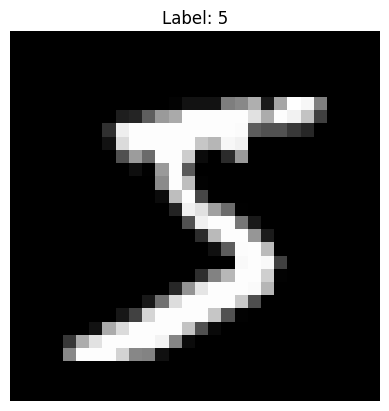

In [3]:
plt.imshow(X_train[0], cmap='gray')
plt.title(f'Label: {y_train[0]}')
plt.axis('off')
plt.show()

### Step 1.4 — Build & Train Baseline

```
Input (784) → Dense 256 ReLU → Dense 128 ReLU → Output 10 Softmax
```

In [4]:
def build_baseline():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(10,  activation='softmax')
    ], name='Baseline')
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_base = build_baseline()
model_base.summary()

Model: "Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9985 - loss: 0.0050 - val_accuracy: 0.9813 - val_loss: 0.1014
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9979 - loss: 0.0060 - val_accuracy: 0.9823 - val_loss: 0.1105
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9984 - loss: 0.0042 - val_accuracy: 0.9815 - val_loss: 0.1132
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9984 - loss: 0.0058 - val_accuracy: 0.9810 - val_loss: 0.1096
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9979 - loss: 0.0059 - val_accuracy: 0.9797 - val_loss: 0.1208
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9979 - loss: 0.0059 - val_accuracy: 0.9827 - val_loss: 0.1103
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9979 - loss: 0.0064 - val_accuracy: 0.9782 - val_loss: 0.1380
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9976 - loss: 0.0072 - val_accuracy: 0

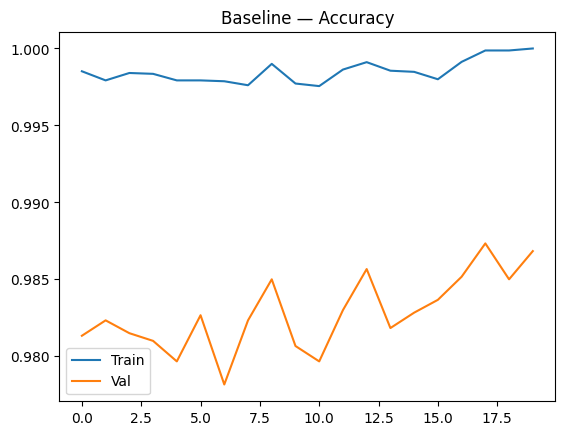

In [16]:
history_base = model_base.fit(
    X_train_f, y_train_ohe,
    epochs=20, batch_size=128, validation_split=0.1, verbose=1
)

loss_base, acc_base = model_base.evaluate(X_test_f, y_test_ohe, verbose=0)
print(f"Baseline — Test Accuracy: {acc_base*100:.2f}%")

# Quick accuracy plot
plt.plot(history_base.history['accuracy'],     label='Train')
plt.plot(history_base.history['val_accuracy'], label='Val')
plt.title('Baseline — Accuracy'); plt.legend(); plt.show()

### Step 1.5 — One Prediction Sample

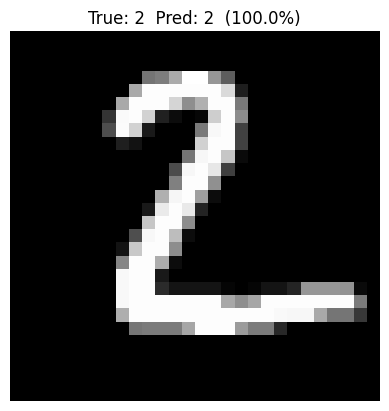

In [17]:
preds = model_base.predict(X_test_f, verbose=0)
pred_labels = np.argmax(preds, axis=1)

idx = 1
plt.imshow(X_test[idx], cmap='gray')
plt.title(f'True: {y_test[idx]}  Pred: {pred_labels[idx]}  ({preds[idx][pred_labels[idx]]*100:.1f}%)')
plt.axis('off')
plt.show()

---
## Stage 2 — Intentional Overfitting

Larger model + more epochs → training accuracy keeps rising while validation plateaus.

Train: 99.84%  Val: 98.20%  Gap: 1.64%


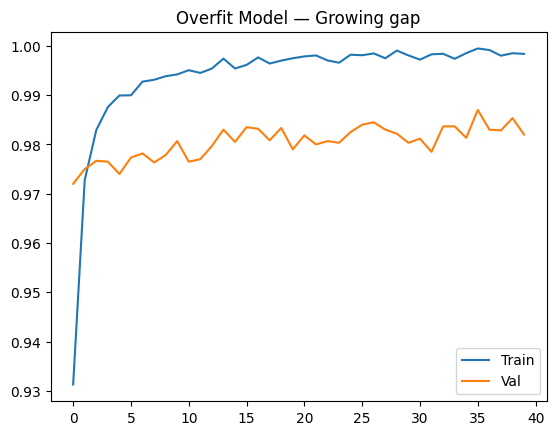

In [7]:
def build_overfit_model():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation='relu'),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(10,  activation='softmax')
    ], name='Overfit_Model')
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_overfit = build_overfit_model()

history_overfit = model_overfit.fit(
    X_train_f, y_train_ohe,
    epochs=40, batch_size=128, validation_split=0.1, verbose=0
)

_, acc_of = model_overfit.evaluate(X_test_f, y_test_ohe, verbose=0)
tr_of  = history_overfit.history['accuracy'][-1]
val_of = history_overfit.history['val_accuracy'][-1]
print(f"Train: {tr_of*100:.2f}%  Val: {val_of*100:.2f}%  Gap: {(tr_of-val_of)*100:.2f}%")

plt.plot(history_overfit.history['accuracy'],     label='Train')
plt.plot(history_overfit.history['val_accuracy'], label='Val')
plt.title('Overfit Model — Growing gap'); plt.legend(); plt.show()

---
## Stage 3A — Fix with Dropout

`Dropout(0.3)` randomly zeros 30% of neurons each training step → forces more robust features.

Train: 97.23%  Val: 98.37%  Gap: -1.13%


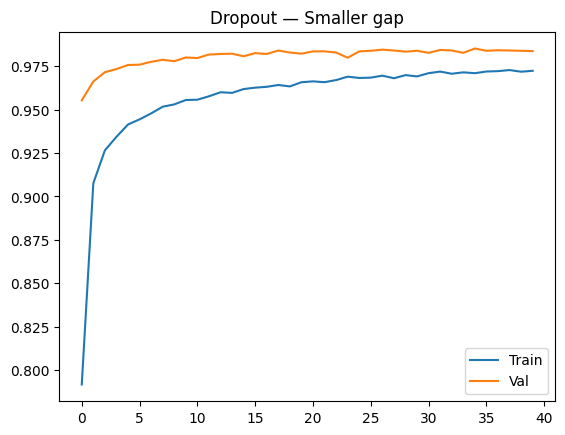

In [18]:
def build_dropout_model():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.7),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.7),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(10,  activation='softmax')
    ], name='Dropout_Model')
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_dropout = build_dropout_model()

history_dropout = model_dropout.fit(
    X_train_f, y_train_ohe,
    epochs=40, batch_size=128, validation_split=0.1, verbose=0
)

_, acc_drop = model_dropout.evaluate(X_test_f, y_test_ohe, verbose=0)
tr_d  = history_dropout.history['accuracy'][-1]
val_d = history_dropout.history['val_accuracy'][-1]
print(f"Train: {tr_d*100:.2f}%  Val: {val_d*100:.2f}%  Gap: {(tr_d-val_d)*100:.2f}%")

plt.plot(history_dropout.history['accuracy'],     label='Train')
plt.plot(history_dropout.history['val_accuracy'], label='Val')
plt.title('Dropout — Smaller gap'); plt.legend(); plt.show()

---
## Stage 3B — Fix with L2 Regularization

$$\text{Loss} = \text{CrossEntropy} + \lambda \sum w^2$$

Penalizes large weights → pushes them toward smaller, more distributed values.

Train: 98.89%  Val: 97.63%  Gap: 1.26%


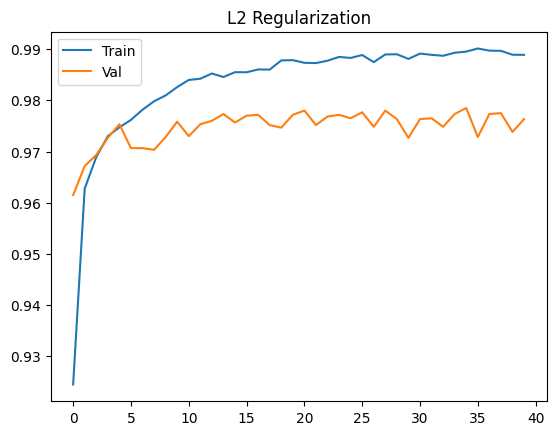

In [9]:
def build_l2_model(lam=0.001):
    reg = regularizers.l2(lam)
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation='relu', kernel_regularizer=reg),
        layers.Dense(512, activation='relu', kernel_regularizer=reg),
        layers.Dense(256, activation='relu', kernel_regularizer=reg),
        layers.Dense(10,  activation='softmax')
    ], name='L2_Model')
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_l2 = build_l2_model(lam=0.001)

history_l2 = model_l2.fit(
    X_train_f, y_train_ohe,
    epochs=40, batch_size=128, validation_split=0.1, verbose=0
)

_, acc_l2 = model_l2.evaluate(X_test_f, y_test_ohe, verbose=0)
tr_l2  = history_l2.history['accuracy'][-1]
val_l2 = history_l2.history['val_accuracy'][-1]
print(f"Train: {tr_l2*100:.2f}%  Val: {val_l2*100:.2f}%  Gap: {(tr_l2-val_l2)*100:.2f}%")

plt.plot(history_l2.history['accuracy'],     label='Train')
plt.plot(history_l2.history['val_accuracy'], label='Val')
plt.title('L2 Regularization'); plt.legend(); plt.show()

---
## Stage 3C — Fix with L1 Regularization

$$\text{Loss} = \text{CrossEntropy} + \lambda \sum |w|$$

Pushes many weights to exactly **zero** (sparsity / feature selection).

Train: 99.04%  Val: 97.77%  Gap: 1.27%


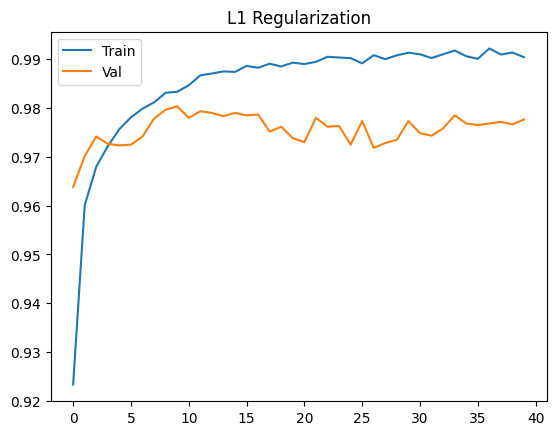

In [10]:
def build_l1_model(lam=0.0001):
    reg = regularizers.l1(lam)
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation='relu', kernel_regularizer=reg),
        layers.Dense(512, activation='relu', kernel_regularizer=reg),
        layers.Dense(256, activation='relu', kernel_regularizer=reg),
        layers.Dense(10,  activation='softmax')
    ], name='L1_Model')
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_l1 = build_l1_model(lam=0.0001)

history_l1 = model_l1.fit(
    X_train_f, y_train_ohe,
    epochs=40, batch_size=128, validation_split=0.1, verbose=0
)

_, acc_l1 = model_l1.evaluate(X_test_f, y_test_ohe, verbose=0)
tr_l1  = history_l1.history['accuracy'][-1]
val_l1 = history_l1.history['val_accuracy'][-1]
print(f"Train: {tr_l1*100:.2f}%  Val: {val_l1*100:.2f}%  Gap: {(tr_l1-val_l1)*100:.2f}%")

plt.plot(history_l1.history['accuracy'],     label='Train')
plt.plot(history_l1.history['val_accuracy'], label='Val')
plt.title('L1 Regularization'); plt.legend(); plt.show()

---
## Stage 3D — L1 + L2 Combined (ElasticNet)

$$\text{Loss} = \text{CrossEntropy} + \lambda_1 \sum |w| + \lambda_2 \sum w^2$$

Train: 98.33%  Val: 97.43%  Gap: 0.90%


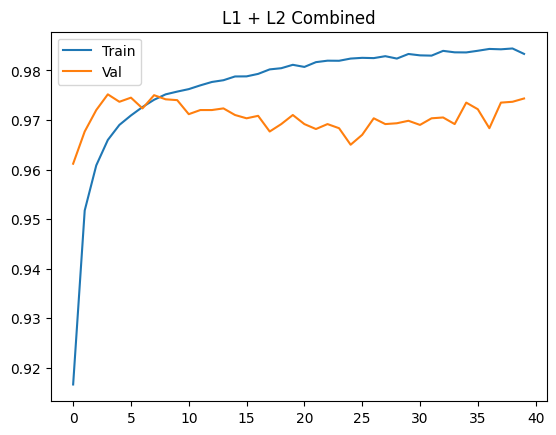

In [11]:
def build_l1l2_model(l1=0.0001, l2=0.001):
    reg = regularizers.l1_l2(l1=l1, l2=l2)
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation='relu', kernel_regularizer=reg),
        layers.Dense(512, activation='relu', kernel_regularizer=reg),
        layers.Dense(256, activation='relu', kernel_regularizer=reg),
        layers.Dense(10,  activation='softmax')
    ], name='L1L2_Model')
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_l1l2 = build_l1l2_model()

history_l1l2 = model_l1l2.fit(
    X_train_f, y_train_ohe,
    epochs=40, batch_size=128, validation_split=0.1, verbose=0
)

_, acc_l1l2 = model_l1l2.evaluate(X_test_f, y_test_ohe, verbose=0)
tr_l1l2  = history_l1l2.history['accuracy'][-1]
val_l1l2 = history_l1l2.history['val_accuracy'][-1]
print(f"Train: {tr_l1l2*100:.2f}%  Val: {val_l1l2*100:.2f}%  Gap: {(tr_l1l2-val_l1l2)*100:.2f}%")

plt.plot(history_l1l2.history['accuracy'],     label='Train')
plt.plot(history_l1l2.history['val_accuracy'], label='Val')
plt.title('L1 + L2 Combined'); plt.legend(); plt.show()

---
## Stage 4 — Compare All Models

In [12]:
results = {
    'Baseline' : (acc_base,  history_base),
    'Overfit'  : (acc_of,    history_overfit),
    'Dropout'  : (acc_drop,  history_dropout),
    'L2'       : (acc_l2,    history_l2),
    'L1'       : (acc_l1,    history_l1),
    'L1 + L2'  : (acc_l1l2,  history_l1l2),
}

print(f"{'Model':<12} {'Test Acc':>10} {'Train Acc':>10} {'Val Acc':>10} {'Gap':>8}")
print("-" * 54)
for name, (test_acc, hist) in results.items():
    tr  = hist.history['accuracy'][-1]
    val = hist.history['val_accuracy'][-1]
    gap = (tr - val) * 100
    print(f"{name:<12} {test_acc*100:>9.2f}% {tr*100:>9.2f}% {val*100:>9.2f}% {gap:>7.2f}%")

Model          Test Acc  Train Acc    Val Acc      Gap
------------------------------------------------------
Baseline         98.03%     99.71%     98.20%    1.51%
Overfit          98.24%     99.84%     98.20%    1.64%
Dropout          98.62%     99.49%     98.43%    1.06%
L2               97.52%     98.89%     97.63%    1.26%
L1               97.48%     99.04%     97.77%    1.27%
L1 + L2          97.25%     98.33%     97.43%    0.90%


---
## Bonus — Confusion Matrix (Best Model)

Best model: Dropout (98.62% test accuracy)


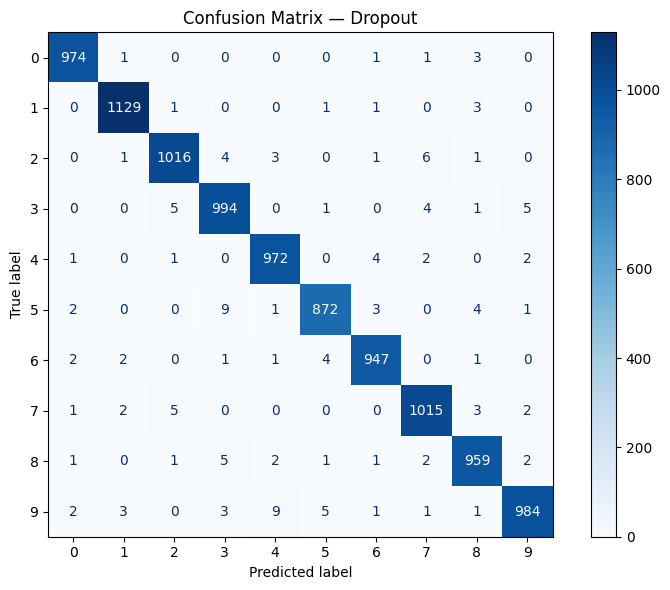


Top 5 Misclassifications:
  True 9 → Pred 4  (9x)
  True 5 → Pred 3  (9x)
  True 2 → Pred 7  (6x)
  True 9 → Pred 5  (5x)
  True 8 → Pred 3  (5x)


In [13]:
best_name = max(results, key=lambda k: results[k][0])
best_models = {
    'Baseline': model_base,
    'Overfit':  model_overfit,
    'Dropout':  model_dropout,
    'L2':       model_l2,
    'L1':       model_l1,
    'L1 + L2':  model_l1l2,
}
best_model = best_models[best_name]
print(f"Best model: {best_name} ({results[best_name][0]*100:.2f}% test accuracy)")

preds_best = best_model.predict(X_test_f, verbose=0)
pred_best  = np.argmax(preds_best, axis=1)
cm         = confusion_matrix(y_test, pred_best)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=range(10)).plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()

errors = sorted([(cm[t,p], t, p) for t in range(10) for p in range(10) if t!=p and cm[t,p]>0], reverse=True)
print("\nTop 5 Misclassifications:")
for count, true, pred in errors[:5]:
    print(f"  True {true} → Pred {pred}  ({count}x)")

---
## Summary

| Technique | Effect | Use when |
|-----------|--------|----------|
| **Baseline** | No regularization | Starting point |
| **Dropout** | Randomly disables neurons | Most common |
| **L2** | Penalizes large weights ($w^2$) | Want smooth weights |
| **L1** | Pushes weights to zero ($|w|$) | Want sparsity |
| **L1+L2** | Both penalties | Best of both |

**Key takeaway:** Regularization closes the train–val gap, making models more reliable on unseen data.